#Project Dissertation Title:

From Unstructured Clinical Notes to Structured Prompts: A Patient-Specific Framework for Few-Shot Chest X-ray Classification

##0. Setup and imports
Import packages, configure BiomedCLIP, set device (GPU), and define utility functions.

In [1]:
## Connect with GG Drive
from google.colab import drive
drive.mount('/content/drive')
import os
folder = '/content/drive/MyDrive/dissertation'

Mounted at /content/drive


In [2]:
# 1 Install dependency
!pip install -q hf_transfer open_clip_torch transformers scikit-learn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 MB 73.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 39.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 2.2 MB/s eta 0:00:00


In [3]:
# 2 Imports
import os
import random
import tarfile
import shutil

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
import torch.nn.functional as F

from PIL import Image
from torchvision import models, transforms
from torch.utils.data import Dataset, DataLoader

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix
)

from open_clip import create_model_from_pretrained, get_tokenizer
import open_clip

In [4]:
# 3 Project configuration
# Reproducibility
seed = 42

random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(seed)

# Device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Project directory
base_dir = "/content/drive/MyDrive/dissertation"

# OpenI dataset path setup openi_images_path
openi_reports_path = f"{base_dir}/openi_reports.csv"
openi_images_path = f"{base_dir}/NLMCXR_png.tgz"
openi_vocab_path = f"{base_dir}/radiology_vocabulary_final.xlsx"
image_weight = 0.4
text_weight = 0.6

prototype_epochs = 100
prototype_lr = 0.001

print(f"Device: {device}")
print(f"Seed: {seed}")

Device: cuda
Seed: 42


In [5]:
# 4 Load BiomedCLIP
# Main VLM used throughout the study
model_config = "BiomedCLIP"
BIOMEDCLIP_MODEL_ID = (
    "hf-hub:microsoft/"
    "BiomedCLIP-PubMedBERT_256-vit_base_patch16_224"
)

clip_model, clip_processor = create_model_from_pretrained(
    BIOMEDCLIP_MODEL_ID
)
clip_tokenizer = get_tokenizer(BIOMEDCLIP_MODEL_ID)

clip_model = clip_model.to(device)
clip_model.eval()

open_clip_config.json:   0%|          | 0.00/707 [00:00<?, ?B/s]

open_clip_pytorch_model.bin: reconstructing file:   0%|          |  0.00B /  784MB            

open_clip_pytorch_model.bin: downloading bytes:           |  0.00B            

config.json:   0%|          | 0.00/385 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/28.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/225k [00:00<?, ?B/s]

CustomTextCLIP(
  (visual): TimmModel(
    (trunk): VisionTransformer(
      (patch_embed): PatchEmbed(
        (proj): Conv2d(3, 768, kernel_size=(16, 16), stride=(16, 16))
        (norm): Identity()
      )
      (pos_drop): Dropout(p=0.0, inplace=False)
      (patch_drop): Identity()
      (norm_pre): Identity()
      (blocks): Sequential(
        (0): Block(
          (norm1): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
          (attn): Attention(
            (qkv): Linear(in_features=768, out_features=2304, bias=True)
            (q_norm): Identity()
            (k_norm): Identity()
            (attn_drop): Dropout(p=0.0, inplace=False)
            (norm): Identity()
            (proj): Linear(in_features=768, out_features=768, bias=True)
            (proj_drop): Dropout(p=0.0, inplace=False)
          )
          (ls1): Identity()
          (drop_path1): Identity()
          (norm2): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
          (mlp): Mlp(
          

##1. Dataset Loading and Initial Inspection
Loads the OpenI reports CSV, the vocabulary spreadsheet (synonyms + hierarchy sheets), and extracts the chest X-ray images.

In [6]:
## Define path
openi_rp_path = openi_reports_path
openi_img_path = openi_images_path
openi_vocab_dict_path = openi_vocab_path

#Read report file
openi_reports= pd.read_csv(openi_rp_path)

#Read dictionary file
vocab_syn = pd.read_excel(openi_vocab_dict_path,sheet_name='synonyms')
vocab_hier = pd.read_excel(openi_vocab_dict_path,sheet_name='hierarchy')

#Read image file
openi_img = "/content/NLMCXR_png"

with tarfile.open(openi_img_path, "r:gz") as tar:tar.extractall(path=openi_img)

/tmp/ipykernel_2361/1598061271.py:16: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  with tarfile.open(openi_img_path, "r:gz") as tar:tar.extractall(path=openi_img)


In [ ]:
# View materials
print(openi_reports.head())
print(vocab_syn.head())
print(os.listdir(openi_img)[:10])

  report_id                                           findings  \
0   CXR3459  Stable appearance of lower cervical fusion XXX...   
1   CXR3348  Stable cardiomegaly. The lungs are clear. Stab...   
2   CXR2070  There are no acute osseous abnormalities. Ques...   
3   CXR1551  The cardiomediastinal silhouette is within nor...   
4   CXR1514  Cardiomediastinal silhouette is within normal ...   

                                          impression  \
0        Negative for acute cardiopulmonary disease.   
1  No acute cardiopulmonary abnormalities. Stable...   
2  Subtle interstitial markings bilateral, may re...   
3             1. No acute intrathoracic abnormality.   
4  1. No acute cardiopulmonary abnormality. 2. Le...   

                                           full_note  \
0  FINDINGS: Stable appearance of lower cervical ...   
1  FINDINGS: Stable cardiomegaly. The lungs are c...   
2  FINDINGS: There are no acute osseous abnormali...   
3  FINDINGS: The cardiomediastinal silhoue

In [7]:
#Check total rows
print(f"Raw CSV rows: {len(openi_reports)}")

Raw CSV rows: 3955


##2. Data Preprocessing

### Filter matched records with images
Not every report has a matching X-ray image, so we list all image files, pull out their report IDs, and keep only reports that have a real image on disk. Drops reports with no image.

In [7]:
## Get all image filenames from the img folder (end with.png)
all_images = [f for root, _, files in os.walk(openi_img)
              for f in files if f.endswith(".png")]

print("Total images:", len(all_images))

report_ids = set(openi_reports['report_id'])
# Extracts report IDs from image filenames, before_
image_ids = set([img.split("_")[0] for img in all_images])
# Filters the reports table to keep only rows where the report ID matches an image that exists, removing any reports with no corresponding image file
oi_report_matched = openi_reports[openi_reports['report_id'].isin(image_ids)].reset_index(drop=True)

#Check dataset after filtering
oi_report_matched


Total images: 7470


,report_id,findings,impression,full_note,mesh_tags
0,CXR3459,Stable appearance of lower cervical fusion XXX...,Negative for acute cardiopulmonary disease.,FINDINGS: Stable appearance of lower cervical ...,"Spinal Fusion/cervical vertebrae, Calcinosis/m..."
1,CXR3348,Stable cardiomegaly. The lungs are clear. Stab...,No acute cardiopulmonary abnormalities. Stable...,FINDINGS: Stable cardiomegaly. The lungs are c...,"Cardiomegaly, Calcinosis/lung/base/left"
2,CXR2070,There are no acute osseous abnormalities. Ques...,"Subtle interstitial markings bilateral, may re...",FINDINGS: There are no acute osseous abnormali...,Markings/lung/base/bilateral/interstitial/prom...
3,CXR1551,The cardiomediastinal silhouette is within nor...,1. No acute intrathoracic abnormality.,FINDINGS: The cardiomediastinal silhouette is ...,normal
4,CXR1514,Cardiomediastinal silhouette is within normal ...,1. No acute cardiopulmonary abnormality. 2. Le...,FINDINGS: Cardiomediastinal silhouette is with...,"Opacity/lung/lingula, Pulmonary Atelectasis/li..."
...,...,...,...,...,...
3846,CXR1390,The heart size and pulmonary vascularity appea...,No evidence of active disease.,FINDINGS: The heart size and pulmonary vascula...,"Catheters, Indwelling"
3847,CXR3426,"The heart, pulmonary XXXX and mediastinum are ...",No acute cardiopulmonary disease.,"FINDINGS: The heart, pulmonary XXXX and medias...",Spine/degenerative/mild
3848,CXR3712,Changes of renal osteodystrophy are noted. Hea...,1. No evidence of active disease.,FINDINGS: Changes of renal osteodystrophy are ...,"Bone Diseases, Metabolic"
3849,CXR2876,There are no focal areas of consolidation. No ...,No acute cardiopulmonary abnormality.,FINDINGS: There are no focal areas of consolid...,normal


### Ontology Building
 Builds RADIOLOGY_ONTOLOGY: a lookup tree with 3 groups.
-  Disease  : per class (Cardiovascular/Respiratory/Musculoskeletal),
 stores anatomy terms (manual) + findings (auto-derived
from the vocab file's coded disease hierarchy, D.1/D.2/D.3).
- Modifier : negation words, used later to filter negated sentences.
- Object   : non-diagnostic terms, used to flag equipment-only reports.

This turns the spreadsheet's flat hierarchy codes into a class-organized tree that later gets synonym-expanded and searched to build structured prompts from raw findings text.

In [8]:
# Add anatomy from CLASS_ANATOMY_TERMS
class_anatomy_terms = {
    "Cardiovascular": ["heart", "aorta", "aorta, thoracic","blood vessels", "coronary vessels","pulmonary artery",
                       "aortic valve","heart atria", "heart ventricles", "mitral valve"],
    "Respiratory": ["lung", "bronchi", "trachea", "pleura","pleural sinus",
                    "pulmonary alveoli","hilum", "base", "apex", "diaphragm"],
    "Musculoskeletal": ["bone and bones", "clavicle", "humerus", "ribs", "spine",
                        "cervical vertebrae","lumbar vertebrae", "thoracic vertebrae","sternum", "shoulder"]
}

# Build RADIOLOGY_ONTOLOGY automatically from vocabulary file
def build_tree_ontology(vocab_hier,class_anatomy_terms):
    ontology = {
        "Disease": {
            "Cardiovascular":{"Anatomy": class_anatomy_terms["Cardiovascular"], "Findings": {}},
            "Respiratory":{"Anatomy": class_anatomy_terms["Respiratory"], "Findings": {}},
            "Musculoskeletal":{"Anatomy": class_anatomy_terms["Musculoskeletal"], "Findings": {}},
            "No Finding":{"Anatomy": [], "Findings": {}}
        },
        "Modifier": {
            "Negation": ["no", "not", "without", "normal","clear", "intact", "negative", "unremarkable"]
        },
        "Object": {
            "NonDiagnostic":(vocab_hier[vocab_hier['Hierarchy'] == 'O']['Term'].dropna().str.lower().str.strip().tolist())
        }
    }

    # Select disease rows from the hierarchy file
    diseases = vocab_hier[vocab_hier['Hierarchy'] == 'D'][['Term', 'with formula']].dropna().copy()
    diseases['Term'] = diseases['Term'].str.lower().str.strip()
    diseases['with formula'] = diseases['with formula'].str.strip()
    code_to_term = dict(zip(diseases['with formula'], diseases['Term']))
    skip_category_codes = {'D', 'D.1', 'D.2', 'D.2.1', 'D.2.2', 'D.2.3', 'D.3', 'D.4'}

    for _, row in diseases.iterrows():
        term = row['Term']
        code = row['with formula']
        # skip broad category rows, only process leaf disease terms
        if code in skip_category_codes:
            continue
        if code.startswith('D.1'):
            cls = 'Cardiovascular'
        elif code.startswith('D.2'):
            cls = 'Respiratory'
        elif code.startswith('D.3'):
            cls = 'Musculoskeletal'
        else:
            continue
        # find nearest parent term
        parent_code = '.'.join(code.split('.')[:-1])
        while parent_code and parent_code not in code_to_term:
            parent_code = '.'.join(parent_code.split('.')[:-1])
        parent_name = code_to_term.get(parent_code, 'other')

        ontology['Disease'][cls]['Findings'].setdefault(parent_name, [])
        ontology['Disease'][cls]['Findings'][parent_name].append(term)
    return ontology

RADIOLOGY_ONTOLOGY = build_tree_ontology(vocab_hier, class_anatomy_terms)

In [9]:
#Check hierchy for Ontology set

for cls, data in RADIOLOGY_ONTOLOGY['Disease'].items():
    if cls == 'No Finding':
        continue
    print(f"\n{cls}:")
    for parent, children in data['Findings'].items():
        print(f"  {parent}:")
        for child in children:
            print(f"    - {child}")


Cardiovascular:
  cardiovascular diseases:
    - aortic aneurysm
    - atherosclerosis
    - cardiomegaly
    - heart failure
    - pericardial effusion

Respiratory:
  bronchial diseases:
    - bronchiectasis
    - bronchitis
  bronchitis:
    - bronchiolitis
  lung diseases:
    - cystic fibrosis
    - hypertension, pulmonary
    - lung, hyperlucent
    - lung diseases, interstitial
    - pneumonia
    - pulmonary atelectasis
    - pulmonary congestion
    - pulmonary disease, chronic obstructive
    - pulmonary edema
    - pulmonary fibrosis
    - tuberculosis
  pleural diseases:
    - hemopneumothorax
    - hemothorax
    - hydropneumothorax
    - pleural effusion
    - pneumothorax

Musculoskeletal:
  musculoskeletal diseases:
    - arthritis
    - bone diseases, metabolic
    - dislocations
    - expansile bone lesions
    - fractures, bone
    - funnel chest
    - hyperostosis, diffuse idiopathic skeletal
    - kyphosis
    - osteophyte
    - pectus carinatum
    - scoliosis
  

### Expand with synonym
Enrich the class-level ontology (anatomy + disease terms) with every known synonym for each term, so downstream string-matching (anatomy extraction, class-level prompt building) can catch a finding

In [10]:
# Find all synonym columns in the vocabulary sheet (any column with "Synonym" in its name)
syn_cols = [c for c in vocab_syn.columns if 'Synonym' in c]

term_synonyms = {}
for _, row in vocab_syn.iterrows():
  #Start with the term
    term = str(row['Term']).lower().strip()
    synonyms = [term]
  #Add each synonym from all synonym columns
    for col in syn_cols:
        val = str(row[col]).lower().strip()
   #skip empty cells
        if val and val != 'nan':
    #Some cells contain multiple synonyms separated by ; then split into three separate terms
            for v in val.split(';'):
                v = v.strip()
                if v:
                    synonyms.append(v)
    term_synonyms[term] = synonyms

print(f"Term synonyms built: {len(term_synonyms)}")

Term synonyms built: 177


In [11]:
# expand anatomy and finding terms with their synonyms while retaining modifier and object categories.
def expand_ontology_with_synonyms(ontology, term_synonyms):
    expanded = {
        "Disease": {},
        "Modifier":ontology.get("Modifier", {}),
        "Object": ontology.get("Object", {})
    }
    for cls_name, cls_data in ontology["Disease"].items():
        expanded["Disease"][cls_name] = {"Anatomy":{},"Findings":{}}
        # expand anatomy terms
        for term in cls_data["Anatomy"]:
            expanded["Disease"][cls_name]["Anatomy"][term] = term_synonyms.get(term, [term])
         # expand findings
        for parent, children in cls_data["Findings"].items():
            for term in children:
                expanded["Disease"][cls_name]["Findings"][term] = term_synonyms.get(term, [term])
    return expanded

expanded_ontology = expand_ontology_with_synonyms(RADIOLOGY_ONTOLOGY, term_synonyms)


In [ ]:
# Verify using 1 example
print("Cardiomegaly synonyms:")
print(expanded_ontology["Disease"]["Cardiovascular"]["Findings"]["cardiomegaly"])
print(f"Total Cardiovascular findings:{len(expanded_ontology['Disease']['Cardiovascular']['Findings'])}")
print(f"Total Respiratory findings:{len(expanded_ontology['Disease']['Respiratory']['Findings'])}")
print(f"Total Musculoskeletal findings:{len(expanded_ontology['Disease']['Musculoskeletal']['Findings'])}")

Cardiomegaly synonyms:
['cardiomegaly', 'cardiac enlargement', 'enlarged heart', 'enlargement heart', 'heart size increased', 'megalocardia']
Total Cardiovascular findings:5
Total Respiratory findings:19
Total Musculoskeletal findings:13


In [12]:
# derive term_to_class_full from expanded ontology
term_to_class_full = {}

for cls_name, cls_data in expanded_ontology["Disease"].items():
    if cls_name == "No Finding":
        continue
    # add all anatomy synonyms
    for canonical, synonyms in cls_data["Anatomy"].items():
        for syn in synonyms:
            term_to_class_full[syn] = cls_name
    # add all finding synonyms
    for canonical, synonyms in cls_data["Findings"].items():
        for syn in synonyms:
            term_to_class_full[syn] = cls_name

print(f"Total terms: {len(term_to_class_full)}")

print("Sample entries:")
for term, cls in list(term_to_class_full.items())[:10]:
    print(f"{term} - {cls}")

Total terms: 215
Sample entries:
heart - Cardiovascular
aorta - Cardiovascular
aortic - Cardiovascular
aortic structure - Cardiovascular
aorta, thoracic - Cardiovascular
thoracic aorta - Cardiovascular
blood vessels - Cardiovascular
coronary vessels - Cardiovascular
coronary arteries - Cardiovascular
coronary veins - Cardiovascular


### Map MeSH Annotations to Diagnostic Classes

This function maps each MeSH annotation to one of the four classes using the term-to-class mapping.
Normal or unindexed studies assigned to `No Finding`. Records containing
only object terms are excluded, while unmatched pathological
terms are temporarily assigned to `Other` and removed from the final dataset.
For studies matching more than one class, a fixed priority rule is applied to
produce a single multiclass label.

In [13]:
# Map MeSH annotations to a single target class.
def get_label(mesh_text):
    # Normal / unindexed studies
    if not mesh_text or str(mesh_text).strip() in ['normal', 'No Indexing', 'nan']:
        return 'No Finding'
    text = str(mesh_text).lower().strip()
    found = set()
    # Match ontology terms to diagnostic classes
    for term, cls in term_to_class_full.items():
        if term in text:
            found.add(cls)
    # use ontology skip terms instead of hardcoded skip_terms
    skip_terms = RADIOLOGY_ONTOLOGY["Object"]["NonDiagnostic"]
    if not found:
        if any(skip in text for skip in skip_terms):
            return None
        return 'Other'
    # Single matched class
    if len(found) == 1:
        return found.pop()
    # Resolve multi-class cases using fixed priority
    priority = ['Respiratory', 'Cardiovascular', 'Musculoskeletal']
    for p in priority:
        if p in found:
            return p

# Apply and check
# Apply label mapping
oi_report_matched['label_hier'] = oi_report_matched['mesh_tags'].apply(get_label)
# Remove excluded and Other cases
oi_final = oi_report_matched[oi_report_matched['label_hier'].notna()].reset_index(drop=True)
oi_final = oi_final[oi_final['label_hier'] != 'Other'].reset_index(drop=True)
oi_final['label_final'] = oi_final['label_hier']

print(oi_final['label_final'].value_counts())
print(f"Total: {len(oi_final)}")

label_final
Respiratory        1570
No Finding         1471
Musculoskeletal     340
Cardiovascular      269
Name: count, dtype: int64
Total: 3650


### Link reports to images

Each processed report is linked to its corresponding image using the study identifier. When multiple images are available for the same
study, only the first image is retained to maintain one image per report and
a consistent input format across the dataset. Records without a matched image
are removed before the final class set is defined.

In [14]:
# Create image paths for each study
image_path_dict = {}

for root, _, files in os.walk(openi_img):
    for f in sorted(files):
        if not f.endswith(".png"):
            continue

        cxr_id = f.split("_")[0]

        # Keep only the first image for each study
        if cxr_id not in image_path_dict:
            image_path_dict[cxr_id] = os.path.join(root, f)

In [15]:
# Link reports to images
oi_final['image_path'] = oi_final['report_id'].map(image_path_dict)

# Check
print(f"Images matched: {oi_final['image_path'].notna().sum()}/{len(oi_final)}")

# Remove reports without matched image
oi_final = oi_final[oi_final['image_path'].notna()].reset_index(drop=True)

print(f"Final dataset:{len(oi_final)}")
print(oi_final['label_final'].value_counts())

Images matched: 3650/3650
Final dataset:3650
label_final
Respiratory        1570
No Finding         1471
Musculoskeletal     340
Cardiovascular      269
Name: count, dtype: int64


In [16]:
# Define final class set
class_names = sorted(oi_final['label_final'].unique().tolist())
num_classes = len(class_names)

print(f"\nClasses ({num_classes}): {class_names}")


Classes (4): ['Cardiovascular', 'Musculoskeletal', 'No Finding', 'Respiratory']


### Train/val/test split
Splits oi_final into train/val/test (stratified by class, so each split keeps the same class proportions). Used consistently across all experiments: baseline, zero-shot, few-shot, and framework.

In [17]:
# Train/val/test split
trainval_df, test_df = train_test_split(oi_final, test_size=0.2,random_state=seed,stratify=oi_final['label_final'])
train_df, val_df = train_test_split(trainval_df, test_size=0.1,random_state=seed,stratify=trainval_df['label_final'])

print(f"Train:{len(train_df)}")
print(f"Val:{len(val_df)}")
print(f"Test:{len(test_df)}")
print(f"Test distribution:")
print(test_df['label_final'].value_counts())

Train:2628
Val:292
Test:730
Test distribution:
label_final
Respiratory        314
No Finding         294
Musculoskeletal     68
Cardiovascular      54
Name: count, dtype: int64


#3. Baseline

##Baseline: ResNet50
Standard fully supervised baseline: fine-tunes an ImageNet-pretrained ResNet50 image classifier on the full labelled training set. No clinical text or few-shot prototype learning is used.

Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 110MB/s] 


Epoch 1/10 | Loss: 1.0585 | Val F1: 0.3236
Epoch 2/10 | Loss: 0.9364 | Val F1: 0.3407
Epoch 3/10 | Loss: 0.8970 | Val F1: 0.2992
Epoch 4/10 | Loss: 0.8497 | Val F1: 0.4004
Epoch 5/10 | Loss: 0.7749 | Val F1: 0.3733
Epoch 6/10 | Loss: 0.7428 | Val F1: 0.4213
Epoch 7/10 | Loss: 0.6910 | Val F1: 0.3745
Epoch 8/10 | Loss: 0.5711 | Val F1: 0.4293
Epoch 9/10 | Loss: 0.4980 | Val F1: 0.3951
Epoch 10/10 | Loss: 0.4544 | Val F1: 0.3539

Accuracy: 0.5521
F1: 0.3564
                 precision    recall  f1-score   support

 Cardiovascular       0.07      0.06      0.06        54
Musculoskeletal       0.13      0.09      0.11        68
     No Finding       0.67      0.57      0.61       294
    Respiratory       0.59      0.72      0.65       314

       accuracy                           0.55       730
      macro avg       0.36      0.36      0.36       730
   weighted avg       0.54      0.55      0.54       730



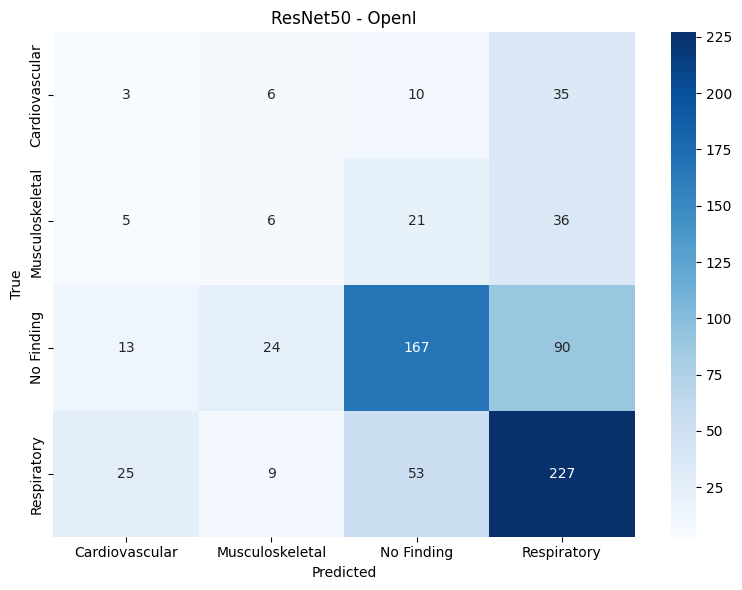

In [ ]:
# Dataset
class OIDataset(Dataset):
    def __init__(self, df, transform=None):
        self.df = df.reset_index(drop=True)
        self.transform = transform
        self.class_to_idx = {c: i for i, c in enumerate(class_names)}

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        image = Image.open(row['image_path']).convert('RGB')
        label = self.class_to_idx[row['label_final']]
        if self.transform:
            image = self.transform(image)
        return image, label

# Transforms
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])
val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

# Loaders
train_loader = DataLoader(OIDataset(train_df, train_transform), batch_size=32,shuffle=True)
val_loader = DataLoader(OIDataset(val_df,val_transform),batch_size=32,shuffle=False)
test_loader = DataLoader(OIDataset(test_df,val_transform),batch_size=32,shuffle=False)

# Model
resnet = models.resnet50(weights='IMAGENET1K_V1')
resnet.fc = nn.Linear(resnet.fc.in_features, num_classes)
resnet = resnet.to(device)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.AdamW(resnet.parameters(), lr=1e-4)

# Train
best_val_f1 = 0
for epoch in range(10):
    resnet.train()
    train_loss = 0
    for imgs, labels in train_loader:
        imgs, labels = imgs.to(device), labels.to(device)
        optimizer.zero_grad()
        loss = criterion(resnet(imgs), labels)
        loss.backward()
        optimizer.step()
        train_loss += loss.item()

    resnet.eval()
    preds_all, labels_all = [], []
    with torch.no_grad():
        for imgs, labels in val_loader:
            preds = resnet(imgs.to(device)).argmax(dim=1).cpu()
            preds_all.extend(preds.tolist())
            labels_all.extend(labels.tolist())

    val_f1 = f1_score(labels_all, preds_all, average='macro')
    print(f"Epoch {epoch+1}/10 | Loss: {train_loss/len(train_loader):.4f} | Val F1: {val_f1:.4f}")

    if val_f1 > best_val_f1:
        best_val_f1 = val_f1
        torch.save(resnet.state_dict(), 'best_resnet_openi.pth')

# Test
resnet.load_state_dict(torch.load('best_resnet_openi.pth'))
resnet.eval()
preds_test, labels_test = [], []
with torch.no_grad():
    for imgs, labels in test_loader:
        preds = resnet(imgs.to(device)).argmax(dim=1).cpu()
        preds_test.extend(preds.tolist())
        labels_test.extend(labels.tolist())

print(f"\nAccuracy: {accuracy_score(labels_test, preds_test):.4f}")
print(f"F1: {f1_score(labels_test, preds_test, average='macro'):.4f}")
print(classification_report(labels_test, preds_test, target_names=class_names))

cm = confusion_matrix(labels_test, preds_test)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('ResNet50 - OpenI')
plt.tight_layout()
plt.show()

## Zero-Shot Baseline: Unstructured note + VLM
Classifies test images by comparing to one real, unedited report per
class (raw clinical text, no structuring) — baseline showing how well
plain unstructured notes work without any prompt engineering.

In [18]:
# Fixed representative notes per class - manually selected
UNSTRUCTURED_CLASS_PROMPTS = {
    "Cardiovascular":
        "FINDINGS: The heart is enlarged. The mediastinum is unremarkable. "
        "Atherosclerotic calcifications present within the thoracic aorta. "
        "There is no pleural effusion, pneumothorax, or focal airspace disease. "
        "Chronic degenerative changes are noted within the spine. "
        "IMPRESSION: 1. Cardiomegaly without acute cardiopulmonary abnormality.",

    "Musculoskeletal":
        "FINDINGS: Stable appearance of lower cervical fusion. "
        "Heart size normal. No pneumothorax or pleural effusion. "
        "No focal airspace disease. Calcified nodules consistent with "
        "chronic granulomatous disease. Bony structures appear intact. "
        "DISH of the thoracic spine. "
        "IMPRESSION: Negative for acute cardiopulmonary disease.",

    "No Finding":
        "FINDINGS: The cardiomediastinal silhouette is normal in size and contour. "
        "No focal consolidation, pneumothorax or large pleural effusion. "
        "Calcified granuloma, right base. Normal cardiomediastinal silhouette. "
        "IMPRESSION: Negative for acute abnormality.",

    "Respiratory":
        "FINDINGS: AP and lateral view of the chest. "
        "IMPRESSION: 1. Cardiomegaly with central vascular congestion and "
        "increased interstitial opacities suggesting mild interstitial pulmonary edema. "
        "2. Small bilateral pleural effusions. 3. No visible pneumothorax.",
}

# Print
for cls in class_names:
    print(f"\n{cls}:")
    print(UNSTRUCTURED_CLASS_PROMPTS[cls])


Cardiovascular:
FINDINGS: The heart is enlarged. The mediastinum is unremarkable. Atherosclerotic calcifications present within the thoracic aorta. There is no pleural effusion, pneumothorax, or focal airspace disease. Chronic degenerative changes are noted within the spine. IMPRESSION: 1. Cardiomegaly without acute cardiopulmonary abnormality.

Musculoskeletal:
FINDINGS: Stable appearance of lower cervical fusion. Heart size normal. No pneumothorax or pleural effusion. No focal airspace disease. Calcified nodules consistent with chronic granulomatous disease. Bony structures appear intact. DISH of the thoracic spine. IMPRESSION: Negative for acute cardiopulmonary disease.

No Finding:
FINDINGS: The cardiomediastinal silhouette is normal in size and contour. No focal consolidation, pneumothorax or large pleural effusion. Calcified granuloma, right base. Normal cardiomediastinal silhouette. IMPRESSION: Negative for acute abnormality.

Respiratory:
FINDINGS: AP and lateral view of the c

In [ ]:
# Unstructured prompts
# One representative note per class
unstructured_prompts = [UNSTRUCTURED_CLASS_PROMPTS[cls] for cls in class_names]
#Encode text
text_tokens = clip_tokenizer(unstructured_prompts).to(device)
with torch.no_grad():
    text_features = F.normalize(clip_model.encode_text(text_tokens), dim=-1)
#Evaluate
preds_all, labels_all = [], []
for _, row in test_df.iterrows():
    image  = Image.open(row['image_path']).convert('RGB')
    tensor = clip_processor(image).unsqueeze(0).to(device)
    with torch.no_grad():
        img_feat = F.normalize(clip_model.encode_image(tensor), dim=-1)
    pred = (img_feat @ text_features.T).argmax(dim=1).item()
    preds_all.append(pred)
    labels_all.append(class_names.index(row['label_final']))

print(f"BiomedCLIP - Unstructured")
print(f"Accuracy: {accuracy_score(labels_all, preds_all):.4f}")
print(f"F1: {f1_score(labels_all, preds_all, average='macro'):.4f}")
print(classification_report(labels_all, preds_all, target_names=class_names))

BiomedCLIP - Unstructured
Accuracy: 0.3890
F1: 0.2247
                 precision    recall  f1-score   support

 Cardiovascular       0.15      0.28      0.20        54
Musculoskeletal       0.10      0.04      0.06        68
     No Finding       0.44      0.87      0.58       294
    Respiratory       0.77      0.03      0.06       314

       accuracy                           0.39       730
      macro avg       0.36      0.31      0.22       730
   weighted avg       0.53      0.39      0.28       730



## Zeros-Shot Baseline: Structured Class Prompt+ VLM
Classifies test images by comparing directly to one fixed, manually structured prompt per class (no training images used) - a zero-shot baseline using template to form structured prompt.

In [19]:
#Define the template to buil structured prompt
OPENI_TEMPLATE_CONFIG = {
    "image_type": "X-ray",
    "body_part":  "chest",

    "classes": {
        "Cardiovascular": {
            "problem":    "cardiovascular disease",
            "anatomy":    ["heart", "aorta"],
            "findings":   ["enlargement", "atherosclerotic calcification"]
        },
        "Musculoskeletal": {
            "problem":    "musculoskeletal disease",
            "anatomy":    ["cervical spine", "thoracic vertebrae"],
            "findings":   ["fusion changes", "degenerative changes"]
        },
        "No Finding": {
            "problem":    "no pathological findings",
            "anatomy":    ["heart", "lungs"],
            "findings":   ["normal size", "no consolidation or effusion"]
        },
        "Respiratory": {
            "problem":    "respiratory disease",
            "anatomy":    ["lungs", "pleura"],
            "findings":   ["interstitial opacities", "pleural effusions"]
        },
    }
}

In [20]:
#Build prompt for each class based on the openi template config
def build_class_prompt(cls, config):
    body = config['body_part']
    img_type = config['image_type']
    c  = config['classes'][cls]
    anatomy_str  = f"{c['anatomy'][0]} and {c['anatomy'][1]}"
    findings_str = f"{c['findings'][0]} and {c['findings'][1]}"
    return (
        f"A {body} {img_type} demonstrating {c['problem']}. "
        f"The {anatomy_str} show {findings_str}."
    )

In [22]:
#Verify prompt
for cls in class_names:
    print(f"\n{cls}:")
    print(build_class_prompt(cls, OPENI_TEMPLATE_CONFIG))


Cardiovascular:
A chest X-ray demonstrating cardiovascular disease. The heart and aorta show enlargement and atherosclerotic calcification.

Musculoskeletal:
A chest X-ray demonstrating musculoskeletal disease. The cervical spine and thoracic vertebrae show fusion changes and degenerative changes.

No Finding:
A chest X-ray demonstrating no pathological findings. The heart and lungs show normal size and no consolidation or effusion.

Respiratory:
A chest X-ray demonstrating respiratory disease. The lungs and pleura show interstitial opacities and pleural effusions.


In [ ]:
#Run model
structured_prompts = [build_class_prompt(cls, OPENI_TEMPLATE_CONFIG) for cls in class_names]

# Encode
text_tokens_struct = clip_tokenizer(structured_prompts).to(device)
with torch.no_grad():
    text_features_struct = F.normalize(clip_model.encode_text(text_tokens_struct), dim=-1)

# Evaluate
preds_struct, labels_struct = [], []
for _, row in test_df.iterrows():
    image  = Image.open(row['image_path']).convert('RGB')
    tensor = clip_processor(image).unsqueeze(0).to(device)
    with torch.no_grad():
        img_feat = F.normalize(
            clip_model.encode_image(tensor), dim=-1)
    pred = (img_feat @ text_features_struct.T).argmax(dim=1).item()
    preds_struct.append(pred)
    labels_struct.append(class_names.index(row['label_final']))

print(f"{model_config} -Structured")
print(f"Accuracy: {accuracy_score(labels_struct, preds_struct):.4f}")
print(f"F1: {f1_score(labels_struct, preds_struct, average='macro'):.4f}")
print(classification_report(labels_struct, preds_struct, target_names=class_names))

BiomedCLIP -Structured
Accuracy: 0.4384
F1: 0.2740
                 precision    recall  f1-score   support

 Cardiovascular       0.18      0.13      0.15        54
Musculoskeletal       0.11      0.13      0.12        68
     No Finding       0.48      0.91      0.62       294
    Respiratory       0.80      0.11      0.20       314

       accuracy                           0.44       730
      macro avg       0.39      0.32      0.27       730
   weighted avg       0.56      0.44      0.36       730



## Few-Shot Baseline: Structured Class Prompt + VLM

Baseline prototype method: one fixed, manually-picked prompt per class
(not patient-specific) is fused with each training image to build the
prototype. Tested at 5/10/20-shot, inference uses image only.

In [21]:
# Compare image-only prototypes vs image + class-level structured prompt prototypes.

def build_class_level_prototype(cls, df, n, use_text=False):

    # Select n examples from this class
    cases = df[df['label_final'] == cls].sample(n=min(n, len(df[df['label_final'] == cls])),random_state=seed)
    image_feats = []

    # Encode each image using BiomedCLIP image encoder
    for _, row in cases.iterrows():
        image = Image.open(row['image_path']).convert('RGB')
        image_tensor = clip_processor(image).unsqueeze(0).to(device)

        with torch.no_grad():
            img_feat = clip_model.encode_image(image_tensor)
            img_feat = F.normalize(img_feat, dim=-1)

        image_feats.append(img_feat)

    # Average n image embeddings to create image prototype
    img_proto = torch.stack(image_feats).mean(dim=0)
    img_proto = F.normalize(img_proto, dim=-1)

    # If no text is used, return image-only prototype
    if not use_text:
        return img_proto

    # Build one structured class-level prompt for this class
    class_prompt = build_class_prompt(cls, OPENI_TEMPLATE_CONFIG)

    # Encode structured prompt using BiomedCLIP text encoder
    text_tokens = clip_tokenizer([class_prompt]).to(device)

    with torch.no_grad():
        text_feat = clip_model.encode_text(text_tokens)
        text_feat = F.normalize(text_feat, dim=-1)

    # Combine image prototype and text embedding
    # 0.5 / 0.5 means image and structured text contribute equally
    combined_proto = F.normalize(0.5 * img_proto + 0.5 * text_feat,dim=-1)

    return combined_proto

In [22]:
# Prototype using image + fixed unstructured class note
def build_unstructured_prototype(cls, df, n):
    cases = df[df['label_final'] == cls].sample(
        n=min(n, len(df[df['label_final'] == cls])), random_state=seed)
    note  = UNSTRUCTURED_CLASS_PROMPTS[cls]  # fixed real note per class
    feats = []
    for _, row in cases.iterrows():
        with torch.no_grad():
            img = clip_processor(Image.open(row['image_path']).convert('RGB')).unsqueeze(0).to(device)
            tokens = clip_tokenizer([note]).to(device)
            img_feat = F.normalize(clip_model.encode_image(img), dim=-1)
            txt_feat = F.normalize(clip_model.encode_text(tokens), dim=-1)
            combined = F.normalize(0.5 * img_feat + 0.5 * txt_feat, dim=-1)
            feats.append(combined.cpu())
    return F.normalize(torch.stack(feats).mean(dim=0), dim=-1).to(device)

In [ ]:
# Few-shot prototype evaluation - compare image-only, unstructured, structured
for n in [5, 10, 20]:
    print(f"\n{n}-shot class level prototype")

    # Build three types of prototypes
    proto_img = torch.cat([build_class_level_prototype(cls, train_df, n, use_text=False) for cls in class_names])
    proto_unstruct = torch.cat([build_unstructured_prototype(cls, train_df, n) for cls in class_names])
    proto_struct = torch.cat([build_class_level_prototype(cls, train_df, n, use_text=True) for cls in class_names])

    for prototypes, name in [(proto_img,"Image only"),(proto_unstruct,"Image + unstructured"),(proto_struct,"Image + structured"),]:
        preds, labels_true = [], []
        for _, row in test_df.iterrows():
            image_tensor = clip_processor(Image.open(row['image_path']).convert('RGB')).unsqueeze(0).to(device)
            with torch.no_grad():
                feat = F.normalize(clip_model.encode_image(image_tensor), dim=-1)
            preds.append((feat @ prototypes.T).argmax(dim=1).item())
            labels_true.append(class_names.index(row['label_final']))

        print(f"{name} - Accuracy: {accuracy_score(labels_true, preds):.4f}  F1: {f1_score(labels_true, preds, average='macro'):.4f}")


5-shot class level prototype
Image only - Accuracy: 0.3671  F1: 0.2652
Image + unstructured - Accuracy: 0.4110  F1: 0.2614
Image + structured - Accuracy: 0.4411  F1: 0.2989

10-shot class level prototype
Image only - Accuracy: 0.4110  F1: 0.2914
Image + unstructured - Accuracy: 0.4466  F1: 0.2914
Image + structured - Accuracy: 0.4712  F1: 0.3220

20-shot class level prototype
Image only - Accuracy: 0.4205  F1: 0.3168
Image + unstructured - Accuracy: 0.4493  F1: 0.2925
Image + structured - Accuracy: 0.4822  F1: 0.3255


# 4.  Patient-Specific Ontology-Guided Prompt Construction
Embedded each text (structured) and image of the records to generate a vector for each class
Generate structured prompts from radiology findings


### Data preprocessing
The patient-specific prompt pipeline:
- removes sentences containing predefined negation or normal-finding terms;
- retains up to two remaining findings;
- identifies anatomy through ontology synonym matching;
- inserts the retained findings and anatomy into a consistent natural-language template.

In [23]:
# Clean findings text for unstructured test condition
oi_final['findings_clean'] = (oi_final['findings'].fillna('').str.replace('XXXX', '', regex=False).str.strip())

In [24]:
def build_findings_structured_prompt(row, config, ontology=RADIOLOGY_ONTOLOGY):
    findings_text = str(row['findings_clean'])
    if not findings_text or findings_text == 'nan':
        return None

    # negations from ontology
    negations = ontology["Modifier"]["Negation"]
    sentences = [s.strip() for s in findings_text.split('.') if len(s.strip()) > 5]
    positive = [s for s in sentences if not any(neg in s.lower() for neg in negations)]
    finding_str = '. '.join(positive[:2]) if positive else sentences[0] if sentences else findings_text
    finding_str = finding_str[:150].strip()

    # anatomy extraction from expanded ontology
    search_text = finding_str.lower()
    anatomy_found = []
    for cls_name, cls_data in expanded_ontology["Disease"].items():
      if cls_name == "No Finding":
          continue
      for term, syn_list in cls_data["Anatomy"].items():
          for syn in syn_list:
              if syn in search_text and term not in anatomy_found:
                  anatomy_found.append(term)
                  break

    anatomy_1 = anatomy_found[0] if len(anatomy_found) > 0 else 'chest'
    anatomy_2 = anatomy_found[1] if len(anatomy_found) > 1 else 'lungs'

    return (
        f"A {config['body_part']} {config['image_type']} "
        f"demonstrating clinical findings. "
        f"The {anatomy_1} and {anatomy_2} show {finding_str}."
    )

# Apply
oi_final['framework_from_findings'] = oi_final.apply(lambda row: build_findings_structured_prompt(row, OPENI_TEMPLATE_CONFIG, RADIOLOGY_ONTOLOGY) or '', axis=1)
# Verify
for i in range(3):
    row = oi_final.iloc[i]
    print(f"Label:{row['label_final']}")
    print(f"Findings:{str(row['findings_clean'])[:80]}")
    print(f"Prompt:{row['framework_from_findings']}")

Label:Musculoskeletal
Findings:Stable appearance of lower cervical fusion . Heart size normal. No pneumothorax 
Prompt:A chest X-ray demonstrating clinical findings. The spine and cervical vertebrae show Stable appearance of lower cervical fusion. DISH of the thoracic spine.
Label:Respiratory
Findings:Stable cardiomegaly. The lungs are clear. Stable left lung base calcifications. 
Prompt:A chest X-ray demonstrating clinical findings. The lung and base show Stable cardiomegaly. Stable left lung base calcifications.
Label:Respiratory
Findings:There are no acute osseous abnormalities. Questionable old left posterior third 
Prompt:A chest X-ray demonstrating clinical findings. The base and lungs show Questionable old left posterior third and fourth rib fractures. Subtle prominence of interstitial markings in the bases, left worse than right.


In [26]:
# Add patient-specific structured prompts to the existing data splits
def add_patient_specific_columns(df):
    df = df.copy()

    # Create cleaned findings
    df["findings_clean"] = (
        df["findings"]
        .fillna("")
        .str.replace("XXXX", "", regex=False)
        .str.strip()
    )

    # Create structured patient-specific prompt
    df["framework_from_findings"] = df.apply(
        lambda row: build_findings_structured_prompt(
            row,
            OPENI_TEMPLATE_CONFIG,
            RADIOLOGY_ONTOLOGY
        ) or "",
        axis=1
    )

    return df


train_df = add_patient_specific_columns(train_df)
val_df = add_patient_specific_columns(val_df)
test_df = add_patient_specific_columns(test_df)

In [ ]:
oi_final

,report_id,findings,impression,full_note,mesh_tags,label_hier,label_final,image_path,findings_clean,framework_from_findings
0,CXR3459,Stable appearance of lower cervical fusion XXX...,Negative for acute cardiopulmonary disease.,FINDINGS: Stable appearance of lower cervical ...,"Spinal Fusion/cervical vertebrae, Calcinosis/m...",Musculoskeletal,Musculoskeletal,/content/NLMCXR_png/CXR3459_IM-1679-1001.png,Stable appearance of lower cervical fusion . H...,A chest X-ray demonstrating clinical findings....
1,CXR3348,Stable cardiomegaly. The lungs are clear. Stab...,No acute cardiopulmonary abnormalities. Stable...,FINDINGS: Stable cardiomegaly. The lungs are c...,"Cardiomegaly, Calcinosis/lung/base/left",Respiratory,Respiratory,/content/NLMCXR_png/CXR3348_IM-1605-1001.png,Stable cardiomegaly. The lungs are clear. Stab...,A chest X-ray demonstrating clinical findings....
2,CXR2070,There are no acute osseous abnormalities. Ques...,"Subtle interstitial markings bilateral, may re...",FINDINGS: There are no acute osseous abnormali...,Markings/lung/base/bilateral/interstitial/prom...,Respiratory,Respiratory,/content/NLMCXR_png/CXR2070_IM-0704-1001.png,There are no acute osseous abnormalities. Ques...,A chest X-ray demonstrating clinical findings....
3,CXR1551,The cardiomediastinal silhouette is within nor...,1. No acute intrathoracic abnormality.,FINDINGS: The cardiomediastinal silhouette is ...,normal,No Finding,No Finding,/content/NLMCXR_png/CXR1551_IM-0359-1001.png,The cardiomediastinal silhouette is within nor...,A chest X-ray demonstrating clinical findings....
4,CXR1514,Cardiomediastinal silhouette is within normal ...,1. No acute cardiopulmonary abnormality. 2. Le...,FINDINGS: Cardiomediastinal silhouette is with...,"Opacity/lung/lingula, Pulmonary Atelectasis/li...",Respiratory,Respiratory,/content/NLMCXR_png/CXR1514_IM-0333-1001.png,Cardiomediastinal silhouette is within normal ...,A chest X-ray demonstrating clinical findings....
...,...,...,...,...,...,...,...,...,...,...
3645,CXR3409,The trachea is midline. The cardiomediastinal ...,No acute cardiopulmonary abnormalities. .,FINDINGS: The trachea is midline. The cardiome...,normal,No Finding,No Finding,/content/NLMCXR_png/CXR3409_IM-1648-1001.png,The trachea is midline. The cardiomediastinal ...,A chest X-ray demonstrating clinical findings....
3646,CXR3426,"The heart, pulmonary XXXX and mediastinum are ...",No acute cardiopulmonary disease.,"FINDINGS: The heart, pulmonary XXXX and medias...",Spine/degenerative/mild,Musculoskeletal,Musculoskeletal,/content/NLMCXR_png/CXR3426_IM-1656-1001.png,"The heart, pulmonary and mediastinum are with...",A chest X-ray demonstrating clinical findings....
3647,CXR3712,Changes of renal osteodystrophy are noted. Hea...,1. No evidence of active disease.,FINDINGS: Changes of renal osteodystrophy are ...,"Bone Diseases, Metabolic",Musculoskeletal,Musculoskeletal,/content/NLMCXR_png/CXR3712_IM-1854-1001.png,Changes of renal osteodystrophy are noted. Hea...,A chest X-ray demonstrating clinical findings....
3648,CXR2876,There are no focal areas of consolidation. No ...,No acute cardiopulmonary abnormality.,FINDINGS: There are no focal areas of consolid...,normal,No Finding,No Finding,/content/NLMCXR_png/CXR2876_IM-1282-1001.png,There are no focal areas of consolidation. No ...,A chest X-ray demonstrating clinical findings....


### Framework Prototype Learning
Builds each class prototype from image + structured findings-prompt
embeddings combined (not just images), so the prototype reflects both
visual and patient-specific clinical text.

In [28]:
# Build prototype for each class using image + structured prompts
def build_findings_prototype(cls,df,n):
    cases = df[df['label_final'] == cls].sample(
        n=min(n,len(df[df['label_final'] == cls])),random_state=seed)
    feats = []
    for _, row in cases.iterrows():
        prompt = row['framework_from_findings']
        if not prompt:
            continue

        with torch.no_grad():
          img=clip_processor(Image.open(row['image_path']).convert('RGB')).unsqueeze(0).to(device)
          tokens = clip_tokenizer([prompt]).to(device)
          #image embedding
          img_feat = F.normalize(clip_model.encode_image(img), dim=-1)
          #text embedding
          txt_feat = F.normalize(clip_model.encode_text(tokens), dim=-1)
          #combine image+findings(structured text)
          combined = F.normalize(image_weight * img_feat + text_weight * txt_feat, dim=-1)

        feats.append(combined.cpu())

    return F.normalize(torch.stack(feats).mean(dim=0), dim=-1).to(device)

In [29]:
# Load one image from disk and encode it into a normalised BiomedCLIP embedding.
def encode_image(row):
    image = Image.open(row['image_path']).convert('RGB')
    image_tensor = clip_processor(image).unsqueeze(0).to(device)

    with torch.no_grad():
        img_feat = clip_model.encode_image(image_tensor)
        img_feat = F.normalize(img_feat, dim=-1)

    return img_feat

In [30]:
# Tokenise and encode one text string into a normalised BiomedCLIP embedding.
def encode_text(text):
    tokens = clip_tokenizer([str(text)]).to(device)

    with torch.no_grad():
        txt_feat = clip_model.encode_text(tokens)
        txt_feat = F.normalize(txt_feat, dim=-1)

    return txt_feat

In [34]:
# Classify every test image by nearest prototype (cosine similarity).
def evaluate_prototype(prototypes, test_text_col=None, img_w=image_weight, txt_w=text_weight):
    preds = []
    labels_true = []

    for _, row in test_df.iterrows():
        img_feat = encode_image(row)

        if test_text_col is not None:
            txt_feat = encode_text(row[test_text_col])
            test_feat = F.normalize(img_w * img_feat + txt_w * txt_feat,dim=-1)
        else:
            test_feat = img_feat

        pred = (test_feat @ prototypes.T).argmax(dim=1).item()

        preds.append(pred)
        labels_true.append(class_names.index(row['label_final']))

    acc = accuracy_score(labels_true, preds)
    f1 = f1_score(labels_true, preds, average='macro')

    return acc, f1

## Framework Inference Evaluation
Tests the same fixed prototypes under 3 inference conditions to
isolate what the structured text actually adds: image alone, image +
raw findings text, and image + the structured framework prompt.

In [32]:
# Build fixed prototypes once for all shot settings
proto_fixed = {}
for n in [5, 10, 20, 50, 100]:
    proto_fixed[n] = torch.cat([build_findings_prototype(cls, train_df, n)for cls in class_names])

In [ ]:
#Run model with negation remove (0.4img/0.6txt)
for n in [5, 10, 20]:
    torch.cuda.empty_cache()
    print(f"\n{n}-shot framework prototype")

    proto_findings = proto_fixed[n]

    acc, f1 = evaluate_prototype(proto_findings,test_text_col=None)
    print(f"Image-only test: Accuracy {acc:.4f} F1 {f1:.4f}")

    acc, f1 = evaluate_prototype(proto_findings,test_text_col='findings_clean')
    print(f"Unstructured findings test: Accuracy {acc:.4f} F1 {f1:.4f}")

    acc, f1 = evaluate_prototype(proto_findings,test_text_col='framework_from_findings')
    print(f"Structured findings test: Accuracy {acc:.4f} F1 {f1:.4f}")


5-shot framework prototype
Image-only test: Accuracy 0.4356 F1 0.2775
Unstructured findings test: Accuracy 0.5479 F1 0.4091
Structured findings test: Accuracy 0.5945 F1 0.5341

10-shot framework prototype
Image-only test: Accuracy 0.4740 F1 0.3284
Unstructured findings test: Accuracy 0.6192 F1 0.4899
Structured findings test: Accuracy 0.6712 F1 0.6074

20-shot framework prototype
Image-only test: Accuracy 0.4699 F1 0.3368
Unstructured findings test: Accuracy 0.6274 F1 0.4759
Structured findings test: Accuracy 0.6671 F1 0.6013


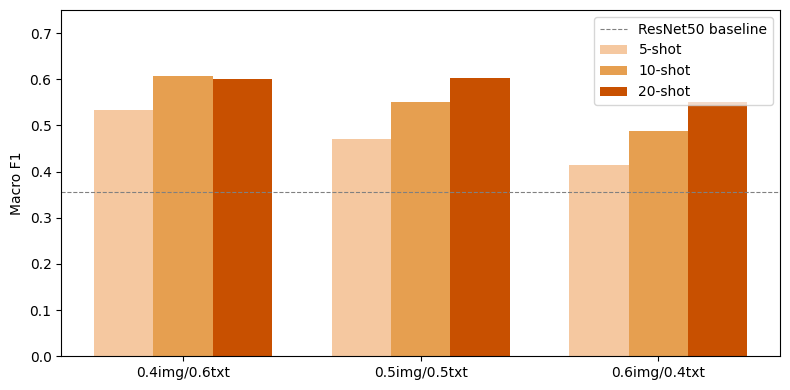

In [36]:
#Fusion Weight Testing Result
import matplotlib.pyplot as plt
weights = ['0.4img/0.6txt', '0.5img/0.5txt', '0.6img/0.4txt']
shot_5 = [0.5341, 0.4710, 0.4146]
shot_10 = [0.6074, 0.5516, 0.4875]
shot_20 = [0.6013, 0.6026, 0.5504]

x = range(len(weights))
width = 0.25

fig, ax = plt.subplots(figsize=(8, 4))
ax.bar([i - width for i in x], shot_5,  width, label='5-shot',  color='#f5c8a0')
ax.bar([i for i in x], shot_10, width, label='10-shot', color='#e69f50')
ax.bar([i + width for i in x], shot_20, width, label='20-shot', color='#c85000')

ax.set_xticks(x)
ax.set_xticklabels(weights)
ax.set_ylabel('Macro F1')
ax.set_ylim(0, 0.75)
ax.legend()
ax.axhline(0.3564, color='gray', linestyle='--', linewidth=0.8, label='ResNet50 baseline')
ax.legend()
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/dissertation/fusion_result',
            format='pdf',
            bbox_inches='tight',
            facecolor='white')
plt.show()

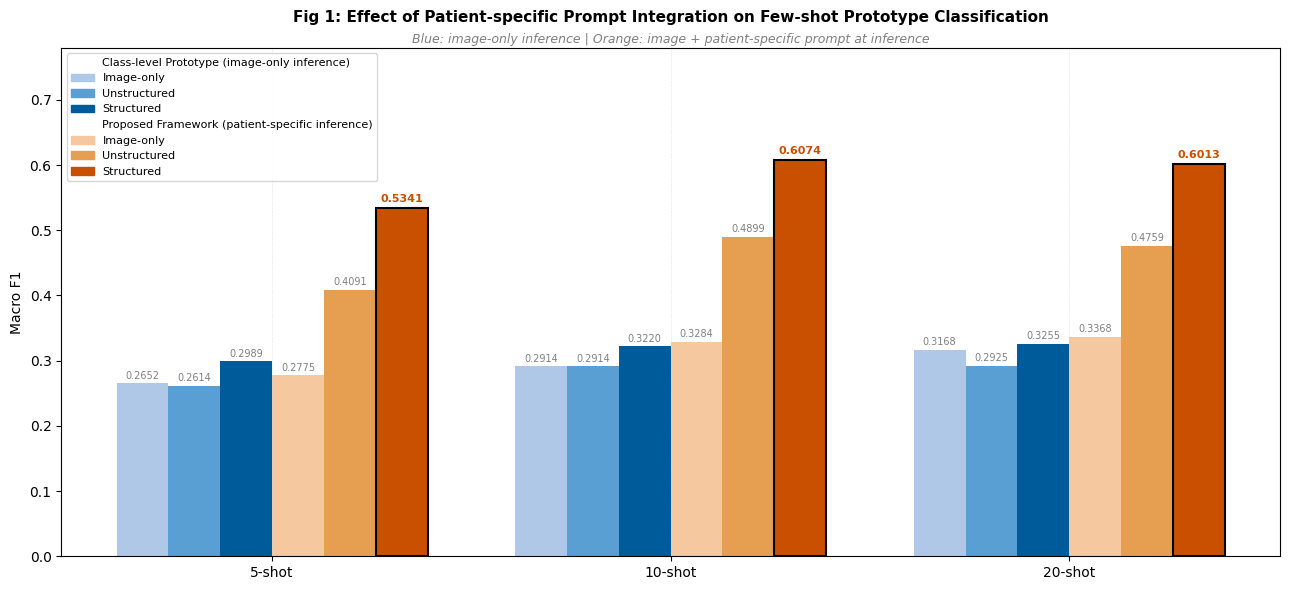

In [ ]:
#Comparison between class-level prototype (inference with image-only) performance vs. proposed framework (image+patient-specific inference)
import matplotlib.pyplot as plt
import numpy as np

shots = ['5-shot', '10-shot', '20-shot']
x = np.arange(len(shots))
width = 0.13

# Prototype Baseline (blue family)
a_img      = [0.2652, 0.2914, 0.3168]
a_unstruct = [0.2614, 0.2914, 0.2925]
a_struct   = [0.2989, 0.3220, 0.3255]

# Ontology-guided Framework (orange family)
b_img      = [0.2775, 0.3284, 0.3368]
b_unstruct = [0.4091, 0.4899, 0.4759]
b_struct   = [0.5341, 0.6074, 0.6013]

fig, ax = plt.subplots(figsize=(13, 6))

# Prototype Baseline — blue family
ax.bar(x - 2.5*width, a_img,      width, label='Prototype Baseline - Image-only',      color='#b0c8e8')
ax.bar(x - 1.5*width, a_unstruct, width, label='Prototype Baseline - Unstructured',     color='#5a9fd4')
ax.bar(x - 0.5*width, a_struct,   width, label='Prototype Baseline - Structured',       color='#005B9A')

# Proposed Framework — orange family
ax.bar(x + 0.5*width, b_img,      width, label='Proposed Framework - Image-only',       color='#f5c8a0')
ax.bar(x + 1.5*width, b_unstruct, width, label='Proposed Framework - Unstructured',     color='#e69f50')
ax.bar(x + 2.5*width, b_struct,   width, label='Proposed Framework - Structured',     color='#c85000',
       edgecolor='black', linewidth=1.5)

# Value labels
for i, bars in enumerate(ax.containers):
    if i == 5:
        for bar in bars:
            height = bar.get_height()
            ax.text(bar.get_x() + bar.get_width()/2, height + 0.01,
                    f'{height:.4f}', ha='center', fontsize=8,
                    fontweight='bold', color='#c85000')
    else:
        ax.bar_label(bars, fmt='%.4f', fontsize=7, padding=2, color='gray')

ax.set_xticks(x)
ax.set_xticklabels(shots)
ax.set_ylabel('Macro F1')

# Title + subtitle
ax.set_title('Fig 1: Effect of Patient-specific Prompt Integration on Few-shot Prototype Classification\n',
             fontsize=11, fontweight='bold')
ax.text(0.5, 1.01,
        'Blue: image-only inference | Orange: image + patient-specific prompt at inference',
        transform=ax.transAxes, ha='center', fontsize=9, color='gray', style='italic')

ax.set_ylim(0, 0.78)

# Divider line between baseline and framework
for xi in x:
    ax.axvline(xi + 0.0, color='lightgray', linestyle=':', linewidth=0.5)

# Legend with two groups
from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0], [0], color='white', label='Class-level Prototype (image-only inference)'),
    plt.Rectangle((0,0),1,1, color='#b0c8e8', label='Image-only'),
    plt.Rectangle((0,0),1,1, color='#5a9fd4', label='Unstructured'),
    plt.Rectangle((0,0),1,1, color='#005B9A', label='Structured'),
    Line2D([0], [0], color='white', label='Proposed Framework (patient-specific inference)'),
    plt.Rectangle((0,0),1,1, color='#f5c8a0', label='Image-only'),
    plt.Rectangle((0,0),1,1, color='#e69f50', label='Unstructured'),
    plt.Rectangle((0,0),1,1, color='#c85000', label='Structured'),
]
ax.legend(handles=legend_elements, fontsize=8, loc='upper left', ncol=1)

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/dissertation/poster_result_chart.png',
            dpi=300, bbox_inches='tight', facecolor='white')
plt.show()

##Learnable
Instead of keeping prototypes fixed at their averaged value, this section lets each class prototype be optimised (via gradient descent on the support set) starting from the fixed prototype. Compares fixed vs. learnable prototypes across shot sizes (5–100) to see when optimisation starts to help.

In [37]:
def build_all_learnable_prototypes_full(df, n, epochs=prototype_epochs, lr=prototype_lr):
    # build fixed prototypes
    init_protos = []
    for cls in class_names:
        with torch.no_grad():
            proto = build_findings_prototype(cls, df, n)
        init_protos.append(proto)
    fixed_protos = F.normalize(torch.cat(init_protos, dim=0), dim=-1)

    # initialise learnable prototypes from fixed
    protos = nn.Parameter(fixed_protos.clone())
    optimizer = torch.optim.Adam([protos], lr=lr)

    # collect support features
    support_feats, support_labels = [], []
    for cls in class_names:
        cases = df[df['label_final'] == cls].sample(
            n=min(n, len(df[df['label_final'] == cls])), random_state=seed)
        for _, row in cases.iterrows():
            with torch.no_grad():
                img = clip_processor(Image.open(row['image_path']).convert('RGB')).unsqueeze(0).to(device)
                tokens = clip_tokenizer([row['framework_from_findings']]).to(device)
                img_feat = F.normalize(clip_model.encode_image(img), dim=-1)
                txt_feat = F.normalize(clip_model.encode_text(tokens), dim=-1)
                feat = F.normalize(image_weight * img_feat + text_weight * txt_feat, dim=-1)
            support_feats.append(feat)
            support_labels.append(class_names.index(cls))

    support_feats  = torch.cat(support_feats, dim=0).to(device)
    support_labels = torch.tensor(support_labels).to(device)
    temperature = 0.07
    loss_history = []

    # optimise
    for epoch in range(epochs):
        optimizer.zero_grad()
        proto_norm = F.normalize(protos, dim=-1)
        logits = support_feats @ proto_norm.T / temperature
        loss = F.cross_entropy(logits, support_labels)
        loss.backward()
        optimizer.step()
        loss_history.append(loss.item())

    learned_protos = F.normalize(protos.detach(), dim=-1)

    # return all on CPU
    return (fixed_protos.cpu(), learned_protos.cpu(),support_feats.cpu(), support_labels.cpu(),loss_history)

In [ ]:
#evaluate learnable vs fix
for n in [5, 10, 20, 50, 100]:
    fixed_p, learned_p, sup_feats, sup_labels, loss_h = build_all_learnable_prototypes_full(train_df, n)

    if n == 20:
        fixed_protos, learned_protos, support_feats, support_labels, losses = fixed_p, learned_p, sup_feats, sup_labels, loss_h
    if n == 50:
        fixed_p_50, learned_p_50, sup_feats_50, sup_labels_50, _ = fixed_p, learned_p, sup_feats, sup_labels, loss_h

    # evaluate fixed
    fixed_gpu = fixed_p.to(device)
    acc_f, f1_f = evaluate_prototype(fixed_gpu, test_text_col='framework_from_findings')

    # evaluate learnable
    learned_gpu = learned_p.to(device)
    acc_l, f1_l = evaluate_prototype(learned_gpu, test_text_col='framework_from_findings')

    print(f"{n}-shot | Fixed F1: {f1_f:.4f} | Learnable F1: {f1_l:.4f}")

5-shot | Fixed F1: 0.5341 | Learnable F1: 0.4786
10-shot | Fixed F1: 0.6074 | Learnable F1: 0.5677
20-shot | Fixed F1: 0.6013 | Learnable F1: 0.6100
50-shot | Fixed F1: 0.6093 | Learnable F1: 0.6585
100-shot | Fixed F1: 0.6249 | Learnable F1: 0.6587


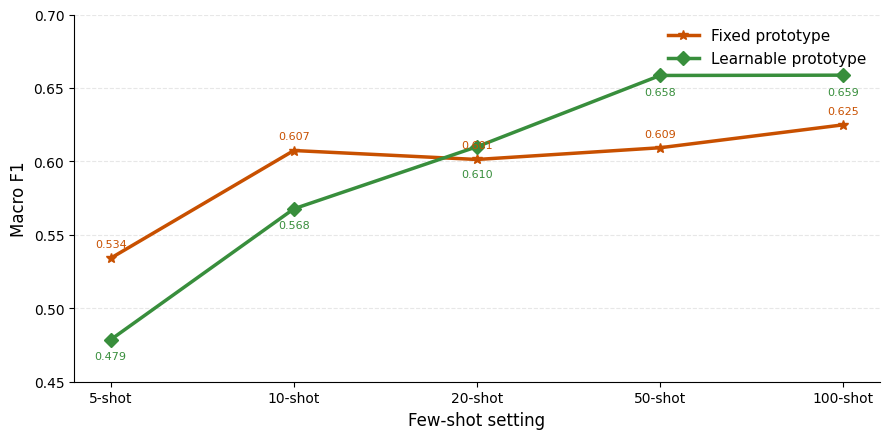

In [ ]:
#Compare fixed prototype and learnable prototype at different shot settings

# Data
shots = [5, 10, 20, 50, 100]
fixed_f1 = [0.5341, 0.6074, 0.6013, 0.6093, 0.6249]
learnable_f1 = [0.4786, 0.5677, 0.6100, 0.6585, 0.6587]

# Evenly spaced x positions
x = range(len(shots))

fig, ax = plt.subplots(figsize=(9, 4.5))

# Plot
ax.plot(
    x, fixed_f1,
    color="#C85000",
    marker="*",
    linewidth=2.5,
    markersize=7,
    label="Fixed prototype"
)

ax.plot(
    x, learnable_f1,
    color="#388E3C",
    marker="D",
    linewidth=2.5,
    markersize=7,
    label="Learnable prototype"
)

# Value labels
for i, y in enumerate(fixed_f1):
    ax.annotate(
        f"{y:.3f}",
        (i, y),
        xytext=(0, 8),
        textcoords="offset points",
        ha="center",
        color="#C85000",
        fontsize=8
    )

for i, y in enumerate(learnable_f1):
    offset = -14

    # Give the 20-shot label a little more room
    if i == 2:
        offset = -22

    ax.annotate(
        f"{y:.3f}",
        (i, y),
        xytext=(0, offset),
        textcoords="offset points",
        ha="center",
        color="#388E3C",
        fontsize=8
    )

# Axes
ax.set_xticks(x)
ax.set_xticklabels([f"{s}-shot" for s in shots], fontsize=10)

ax.set_xlabel("Few-shot setting", fontsize=12)
ax.set_ylabel("Macro F1", fontsize=12)

ax.set_ylim(0.45, 0.70)

# Grid
ax.grid(axis="y", linestyle="--", alpha=0.3)

# Clean look
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

# Legend
ax.legend(frameon=False, fontsize=11)

plt.tight_layout()

plt.savefig(
    "/content/drive/MyDrive/dissertation/fixed_learnable_f1.pdf",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

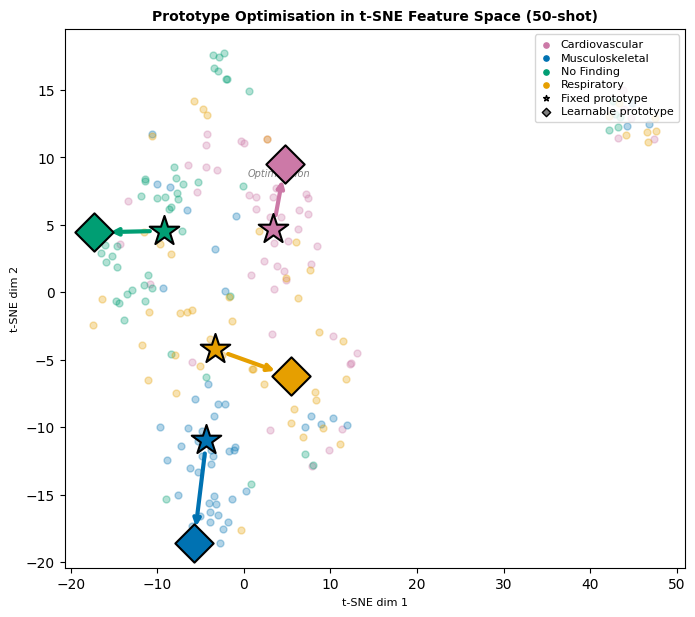

In [39]:
# The TSNE figure support image features + fixed prototypes + learned rototypes into 2D, prototype movement during optimisation can beseen.
# Arrows show fixed -> learned prototype shift for each class, giving qualitative support for the fixed vs. learnable results.

from sklearn.manifold import TSNE
def plot_tsne_simple(fixed_p, learned_p, sup_feats, sup_labels, ax, title):
    # combine for t-SNE — no centroid needed
    all_feats = torch.cat([sup_feats, fixed_p, learned_p], dim=0).numpy()
    embedded = TSNE(n_components=2, random_state=seed, perplexity=15).fit_transform(all_feats)

    n_sup = len(sup_labels)
    n_cls = len(class_names)
    sup_emb     = embedded[:n_sup]
    fixed_emb   = embedded[n_sup:n_sup + n_cls]
    learned_emb = embedded[n_sup + n_cls:]

    colors = {
    'Cardiovascular': '#CC79A7',   # vermillion — safe
    'Musculoskeletal': '#0072B2',  # blue — safe
    'No Finding':     '#009E73',   # teal green — safe
    'Respiratory':    '#E69F00'    # amber — safe
    }

    # support samples
    for i in range(len(sup_emb)):
        cls = class_names[sup_labels[i].item()]
        ax.scatter(sup_emb[i, 0], sup_emb[i, 1],
                   c=colors[cls], marker='o', s=25, alpha=0.3, zorder=2)

    # fixed prototypes
    for i, cls in enumerate(class_names):
        ax.scatter(fixed_emb[i, 0], fixed_emb[i, 1],
                   c=colors[cls], marker='*', s=500,
                   edgecolors='black', linewidths=1.5, zorder=7)

    # learned prototypes
    for i, cls in enumerate(class_names):
        ax.scatter(learned_emb[i, 0], learned_emb[i, 1],
                   c=colors[cls], marker='D', s=380,
                   edgecolors='black', linewidths=1.5, zorder=7)

    # arrows
    for i, cls in enumerate(class_names):
        ax.annotate('',
            xy=(learned_emb[i, 0], learned_emb[i, 1]),
            xytext=(fixed_emb[i, 0], fixed_emb[i, 1]),
            arrowprops=dict(
                arrowstyle='->',
                color=colors[cls],
                lw=3.0,
                shrinkA=10,   # shrink start (away from star)
                shrinkB=12,   # shrink end (away from diamond) — shows arrowhead
                ))

    # single optimisation label
    mid_x = (fixed_emb[0, 0] + learned_emb[0, 0]) / 2
    mid_y = (fixed_emb[0, 1] + learned_emb[0, 1]) / 2
    ax.text(mid_x, mid_y + 1.5, 'Optimisation', fontsize=7,
            color='gray', style='italic', ha='center')

    ax.set_title(title, fontsize=10, fontweight='bold')
    ax.set_xlabel('t-SNE dim 1', fontsize=8)
    ax.set_ylabel('t-SNE dim 2', fontsize=8)

# Plot
fig, ax = plt.subplots(figsize=(8, 7))

plot_tsne_simple(fixed_p_50, learned_p_50,
    sup_feats_50,
    sup_labels_50,
    ax,
    "Prototype Optimisation in t-SNE Feature Space (50-shot)"
)

# Simplified legend — only 6 items
colors_dict = {
    'Cardiovascular': '#CC79A7', 'Musculoskeletal': '#0072B2',
    'No Finding': '#009E73', 'Respiratory': '#E69F00'
}
for cls, col in colors_dict.items():
    ax.scatter([], [], c=col, s=40, label=cls)
ax.scatter([], [], c='gray', marker='*', s=50,
           edgecolors='black', label='Fixed prototype')
ax.scatter([], [], c='gray', marker='D', s=50,
           edgecolors='black', label='Learnable prototype')
ax.legend(fontsize=8, loc='upper right',
          markerscale=0.6, handlelength=1.0,
          borderpad=0.5, labelspacing=0.3)


plt.savefig(
    "/content/drive/MyDrive/dissertation/tsne_poster.pdf",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# 5. Cross-Dataset Evaluation: PadChest-GR
External validation: applies the same framework (no retraining) to PadChest-GR,a different chest X-ray dataset, to check whether the structured prompt approach generalises beyond OpenI.

## Padchest-gr

###Data preprocessing

In [40]:
#Load dataset
import kagglehub
import os

padchest_rp_path = kagglehub.dataset_download("fatihasubha/padchest-gr-1000")
padchest_path = os.path.join(padchest_rp_path, 'PadChest_GR_1000')


100%|██████████| 7.83G/7.83G [07:17<00:00, 19.2MB/s]

Extracting files...


In [ ]:
# check what files exist
print(os.listdir(padchest_path)[:10])
print(os.listdir(padchest_rp_path))

['PadChest_GR_1000', 'filtered_studies_1000.json']
['PadChest_GR_1000']


In [41]:
# load JSON and images
import json
padchest_rp = os.path.join(padchest_rp_path, 'PadChest_GR_1000', 'filtered_studies_1000.json')
padchest_img = os.path.join(padchest_rp_path, 'PadChest_GR_1000', 'PadChest_GR_1000')

# verify images exist
print(os.listdir(padchest_img)[:5])

# load json
with open(padchest_rp, 'r') as f:
    data = json.load(f)

print(f"Total records: {len(data)}")
print(data[0])

['98384954581834328543156824517604283925_oull78.png', '120292101019625933790083964950985919158_u4peud.png', '243013680267016074517015336424453329198_2_86l7wh.png', '50923934216451050755281782636833486515_3vv6xs.png', '297509077432561090401458147497531991674_q7dyul.png']
Total records: 1000
{'StudyID': '227815950113516054835086522832750145371', 'ImageID': '227815950113516054835086522832750145371_eqwp56.png', 'PreviousStudyID': None, 'PreviousImageID': None, 'findings': [{'sentence_en': 'Pacemaker projected over the upper part of the left hemithorax.', 'sentence_es': 'Marcapasos proyectado sobre parte superior del hemitórax izquierdo.', 'abnormal': True, 'boxes': [[0.38252497, 0.18767556, 0.82990132, 0.76762606]], 'extra_boxes': [[0.31302818, 0.1425164, 0.87915948, 0.75144647]], 'labels': ['pacemaker'], 'locations': ['left', 'hemithorax'], 'progression': None}, {'sentence_en': 'Chronic pulmonary changes.', 'sentence_es': 'Cambios pulmonares crónicos.', 'abnormal': True, 'boxes': [], 'ext

In [42]:
#flatten to dataframe
rows = []
for study in data:
    image_path = os.path.join(padchest_img, study['ImagePath'])

    # keep ALL positive findings — no device filtering here
    pos_findings = [
        f['sentence_en'] for f in study['findings']
        if f.get('abnormal', False) and f.get('sentence_en')
    ]

    all_labels = []
    for f in study['findings']:
        if f.get('abnormal', False):
            all_labels.extend(f.get('labels', []))

    rows.append({
        'image_id':    study['ImageID'],
        'image_path':  image_path,
        'findings_en': ' '.join(pos_findings),
        'labels':      all_labels
    })

padchest_df = pd.DataFrame(rows)
print(f"Total: {len(padchest_df)}")

Total: 1000


In [43]:
#Define class label
def get_padchest_label(labels):
    if not labels:
        return 'No Finding'

    # join labels into text and use existing term_to_class_full
    text = ' '.join(labels).lower()

    found = set()
    for term, cls in term_to_class_full.items():
        if term in text:
            found.add(cls)

    # skip if only device terms
    skip_terms_onto = RADIOLOGY_ONTOLOGY["Object"]["NonDiagnostic"]
    if not found:
        if any(skip in text for skip in skip_terms_onto):
            return None
        return 'No Finding'

    if len(found) == 1:
        return found.pop()

    priority = ['Respiratory', 'Cardiovascular', 'Musculoskeletal']
    for p in priority:
        if p in found:
            return p

padchest_df['label_final'] = padchest_df['labels'].apply(get_padchest_label)
padchest_df = padchest_df[padchest_df['label_final'].notna()].reset_index(drop=True)

print(padchest_df['label_final'].value_counts())
print(f"Total: {len(padchest_df)}")

label_final
No Finding         540
Respiratory        226
Cardiovascular     147
Musculoskeletal     87
Name: count, dtype: int64
Total: 1000


In [45]:
#Build Structured Note for Padchest to input in inference time
padchest_df['findings_clean'] = padchest_df['findings_en']

padchest_df['framework_from_findings'] = padchest_df.apply(
    lambda row: build_findings_structured_prompt(
        row, OPENI_TEMPLATE_CONFIG, RADIOLOGY_ONTOLOGY) or '', axis=1)


In [29]:
#Check data
padchest_df

,image_id,image_path,findings_en,labels,label_final,findings_clean,framework_from_findings
0,227815950113516054835086522832750145371_eqwp56...,/root/.cache/kagglehub/datasets/fatihasubha/pa...,Pacemaker projected over the upper part of the...,"[pacemaker, chronic changes, goiter]",No Finding,Pacemaker projected over the upper part of the...,A chest X-ray demonstrating clinical findings....
1,43051905035098365444692863202744592767_tyirs8.png,/root/.cache/kagglehub/datasets/fatihasubha/pa...,Marked cardiomegaly. Slight perihilar and biba...,"[cardiomegaly, interstitial pattern]",Cardiovascular,Marked cardiomegaly. Slight perihilar and biba...,A chest X-ray demonstrating clinical findings....
2,114228248875536980482660826348807300993_op6uxb...,/root/.cache/kagglehub/datasets/fatihasubha/pa...,Cardiac prosthetic valve. Dual chamber pacemak...,"[artificial heart valve, dual chamber device, ...",Cardiovascular,Cardiac prosthetic valve. Dual chamber pacemak...,A chest X-ray demonstrating clinical findings....
3,227615186177347518769763483307917843248_qson7b...,/root/.cache/kagglehub/datasets/fatihasubha/pa...,Aortic elongation. Left basal laminar atelecta...,"[aortic elongation, laminar atelectasis]",Respiratory,Aortic elongation. Left basal laminar atelecta...,A chest X-ray demonstrating clinical findings....
4,30611528127380266061394295549683298444_c6x8s8.png,/root/.cache/kagglehub/datasets/fatihasubha/pa...,Chronic pulmonary changes. Prominent right hil...,"[chronic changes, vascular hilar enlargement]",No Finding,Chronic pulmonary changes. Prominent right hil...,A chest X-ray demonstrating clinical findings....
...,...,...,...,...,...,...,...
995,219198732434843734214368642888479345169_fqkpyg...,/root/.cache/kagglehub/datasets/fatihasubha/pa...,Slight kyphosis. Ossification of paravertebral...,"[kyphosis, axial hyperostosis, suture material...",Cardiovascular,Slight kyphosis. Ossification of paravertebral...,A chest X-ray demonstrating clinical findings....
996,109876241481532572619807710001909166420_dln48o...,/root/.cache/kagglehub/datasets/fatihasubha/pa...,,[],No Finding,,
997,240901793831868002350241513124822033145_bnzkfq...,/root/.cache/kagglehub/datasets/fatihasubha/pa...,Bulla in the left upper lobe. Increased bronch...,"[bullas, bronchovascular markings]",No Finding,Bulla in the left upper lobe. Increased bronch...,A chest X-ray demonstrating clinical findings....
998,131027239880063589528298877043823864155_nfoq2d...,/root/.cache/kagglehub/datasets/fatihasubha/pa...,Cardiomegaly. Congestive hila.,"[cardiomegaly, hilar congestion]",Cardiovascular,Cardiomegaly. Congestive hila.,A chest X-ray demonstrating clinical findings....


### Test model

In [42]:
# Build OpenI 20-shot prototypes
proto_unstruct_20 = torch.cat([build_unstructured_prototype(cls, train_df, 20)
    for cls in class_names])
proto_struct_20 = torch.cat([build_findings_prototype(cls, train_df, 20)
    for cls in class_names])
fixed_p, learned_p, sup_feats, sup_labels, losses = (build_all_learnable_prototypes_full(train_df, 20))
proto_learnable_20 = learned_p.to(device)

In [43]:
#save prototypr
PROTOTYPE_DIR = f"{base_dir}"
os.makedirs(PROTOTYPE_DIR, exist_ok=True)

torch.save(proto_unstruct_20.cpu(), f"{PROTOTYPE_DIR}/proto_unstruct_20.pt")

torch.save(proto_struct_20.cpu(),f"{PROTOTYPE_DIR}/proto_struct_20.pt")

torch.save(proto_learnable_20.cpu(),f"{PROTOTYPE_DIR}/proto_learnable_20.pt")

In [44]:
#Load prototype

proto_unstruct_20 = torch.load(f"{PROTOTYPE_DIR}/proto_unstruct_20.pt").to(device)
proto_struct_20 = torch.load(f"{PROTOTYPE_DIR}/proto_struct_20.pt").to(device)
proto_learnable_20 = torch.load(f"{PROTOTYPE_DIR}/proto_learnable_20.pt").to(device)


In [45]:
#Define evaluation function

def encode_image(row):
    image = Image.open(row['image_path']).convert('RGB')
    image_tensor = clip_processor(image).unsqueeze(0).to(device)

    with torch.no_grad():
        img_feat = clip_model.encode_image(image_tensor)
        img_feat = F.normalize(img_feat, dim=-1)

    return img_feat
def evaluate_padchest(prototypes, test_text_col=None, img_w=image_weight, txt_w=text_weight):
    preds, labels_true = [], []
    for _, row in padchest_df.iterrows():
        img_feat = encode_image(row)
        if test_text_col is not None:
            txt_feat = encode_text(row[test_text_col])
            test_feat = F.normalize(img_w * img_feat + txt_w * txt_feat, dim=-1)
        else:
            test_feat = img_feat
        pred = (test_feat @ prototypes.T).argmax(dim=1).item()
        preds.append(pred)
        labels_true.append(class_names.index(row['label_final']))
    acc = accuracy_score(labels_true, preds)
    f1  = f1_score(labels_true, preds, average='macro')
    return acc, f1

In [ ]:
#Experiment 1 - image-only inference on PadChest
for proto, name in [
    (proto_unstruct_20,'Unstructured proto'),
    (proto_struct_20, 'Structured proto'),
    (proto_learnable_20,'Learnable proto')
]:
    acc, f1 = evaluate_padchest(proto, test_text_col=None)
    print(f"{name} | Image-only: F1 {f1:.4f} Accuravy {acc:.4f}")

Unstructured proto | Image-only: F1 0.2564
Structured proto | Image-only: F1 0.2185
Learnable proto | Image-only: F1 0.2123


In [46]:
#Experiment 1 - image-only inference on PadChest
for proto, name in [
    (proto_unstruct_20,'Unstructured proto'),
    (proto_struct_20, 'Structured proto'),
    (proto_learnable_20,'Learnable proto')
]:
    acc, f1 = evaluate_padchest(proto, test_text_col=None)
    print(f"{name} | Image-only: F1 {f1:.4f} Accuravy {acc:.4f}")

Unstructured proto | Image-only: F1 0.2564 Accuravy 0.4870
Structured proto | Image-only: F1 0.2185 Accuravy 0.4090
Learnable proto | Image-only: F1 0.2123 Accuravy 0.4440


In [ ]:
# Experiment 2 - structured prompt at inference on PadChest
for proto, name in [
    (proto_unstruct_20, 'Unstructured proto'),
    (proto_struct_20, 'Structured proto'),
    (proto_learnable_20,'Learnable proto')
]:
    acc, f1 = evaluate_padchest(proto, test_text_col='framework_from_findings')
    print(f"{name} | Structured inference: F1 {f1:.4f} Accuracy {acc:.4f}")

Unstructured proto | Structured inference: F1 0.3127 Accuracy 0.3160
Structured proto | Structured inference: F1 0.6083 Accuracy 0.6710
Learnable proto | Structured inference: F1 0.4200 Accuracy 0.4010
